# TokTok: Custom Spanish Tokenizer

Train a BPE tokenizer on Spanish Wikipedia and compare it against general-purpose tokenizers (GPT-4, Llama).

The big question: **how much efficiency do general-purpose tokenizers leave on the table for Spanish?** And what's the tradeoff — what do you give up by going language-specific?

In [1]:
import os
import sentencepiece as spm
import tiktoken
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter

## 1. Download and prepare data

Run `python download_data.py --english` first to get the wikipedia dumps.
We use 100K spanish articles and 20K english articles.

In [2]:
# check data exists
for f in ["data/es_wiki.txt", "data/en_wiki.txt"]:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024 * 1024)
        print(f"{f}: {size:.1f} MB")
    else:
        print(f"{f}: NOT FOUND - run download_data.py first")

data/es_wiki.txt: 8.3 MB
data/en_wiki.txt: 128.4 MB


## 2. Train tokenizers at multiple vocab sizes

We train 3 BPE tokenizers on the spanish corpus with different vocab sizes to find the sweet spot.

In [3]:
from train_tokenizer import train_tokenizer, load_and_test

VOCAB_SIZES = [8_000, 32_000, 64_000]
models = {}

for vs in VOCAB_SIZES:
    model_path = train_tokenizer(
        input_file="data/es_wiki.txt",
        vocab_size=vs,
        output_dir="models",
    )
    sp = spm.SentencePieceProcessor()
    sp.load(f"{model_path}.model")
    models[f"toktok_{vs // 1000}k"] = sp
    print(f"Loaded toktok_{vs // 1000}k (vocab: {sp.get_piece_size():,})")

Model already exists at models/sp_bpe_8k.model
Loaded toktok_8k (vocab: 8,000)
Model already exists at models/sp_bpe_32k.model
Loaded toktok_32k (vocab: 32,000)
Model already exists at models/sp_bpe_64k.model
Loaded toktok_64k (vocab: 64,000)


## 3. Load baseline tokenizers

We compare against:
- **tiktoken cl100k** (GPT-4): 100K vocab, byte-level BPE, trained mostly on english
- **Llama 3 tokenizer**: 128K vocab, BPE, more multilingual than GPT

In [4]:
# GPT-4 tokenizer
gpt4_enc = tiktoken.get_encoding("cl100k_base")
print(f"GPT-4 (cl100k): {gpt4_enc.n_vocab:,} tokens")

# Llama 3 tokenizer (using NousResearch mirror to avoid gated access)
llama_tok = AutoTokenizer.from_pretrained("NousResearch/Meta-Llama-3.1-8B")
print(f"Llama 3: {llama_tok.vocab_size:,} tokens")

GPT-4 (cl100k): 100,277 tokens


Llama 3: 128,000 tokens


## 4. Compression comparison

The key metric: how many tokens does each tokenizer need for the same text?

**Important caveat**: our tokenizer spends its entire vocab budget on Spanish, while GPT-4 (100K vocab) and Llama 3 (128K vocab) spread theirs across all languages + code. A Spanish-only tokenizer *should* beat them on Spanish — the question is by how much, and what's the cost on English.

In [5]:
test_texts = {
    "es_short": "El procesamiento de lenguaje natural es una rama de la inteligencia artificial que se enfoca en la interaccion entre computadoras y el lenguaje humano.",
    "es_technical": "Los modelos de lenguaje basados en transformers utilizan mecanismos de atencion para procesar secuencias de tokens en paralelo, lo que permite un entrenamiento mucho mas eficiente que las redes recurrentes.",
    "es_news": "El presidente anuncio nuevas medidas economicas para enfrentar la inflacion que ha afectado a millones de familias en todo el pais durante los ultimos meses.",
    "en_short": "Natural language processing is a branch of artificial intelligence that focuses on the interaction between computers and human language.",
    "en_technical": "Transformer-based language models use attention mechanisms to process token sequences in parallel, enabling much more efficient training than recurrent neural networks.",
    "en_news": "The president announced new economic measures to address inflation that has affected millions of families across the country in recent months.",
}


def count_tokens(text, tokenizer, tokenizer_type="sp"):
    """Count tokens for a text using different tokenizer types."""
    if tokenizer_type == "sp":
        return len(tokenizer.encode_as_ids(text))
    elif tokenizer_type == "tiktoken":
        return len(tokenizer.encode(text))
    elif tokenizer_type == "hf":
        return len(tokenizer.encode(text))


# build comparison table
rows = []
for text_name, text in test_texts.items():
    lang = "Spanish" if text_name.startswith("es") else "English"
    n_chars = len(text)

    # our tokenizers
    for name, sp in models.items():
        n_tokens = count_tokens(text, sp, "sp")
        rows.append({"text": text_name, "lang": lang, "tokenizer": name, "n_tokens": n_tokens, "n_chars": n_chars, "compression": n_chars / n_tokens})

    # GPT-4
    n_tokens = count_tokens(text, gpt4_enc, "tiktoken")
    rows.append({"text": text_name, "lang": lang, "tokenizer": "gpt4", "n_tokens": n_tokens, "n_chars": n_chars, "compression": n_chars / n_tokens})

    # Llama
    n_tokens = count_tokens(text, llama_tok, "hf")
    rows.append({"text": text_name, "lang": lang, "tokenizer": "llama3", "n_tokens": n_tokens, "n_chars": n_chars, "compression": n_chars / n_tokens})

df = pd.DataFrame(rows)

# pivot: average compression by language and tokenizer
summary = df.groupby(["lang", "tokenizer"])["compression"].mean().unstack()
print("Average compression (chars/token):")
print(summary.round(2))

Average compression (chars/token):
tokenizer  gpt4  llama3  toktok_32k  toktok_64k  toktok_8k
lang                                                      
English    6.75    6.46        3.33        3.68       2.81
Spanish    4.45    4.34        5.43        5.59       4.71


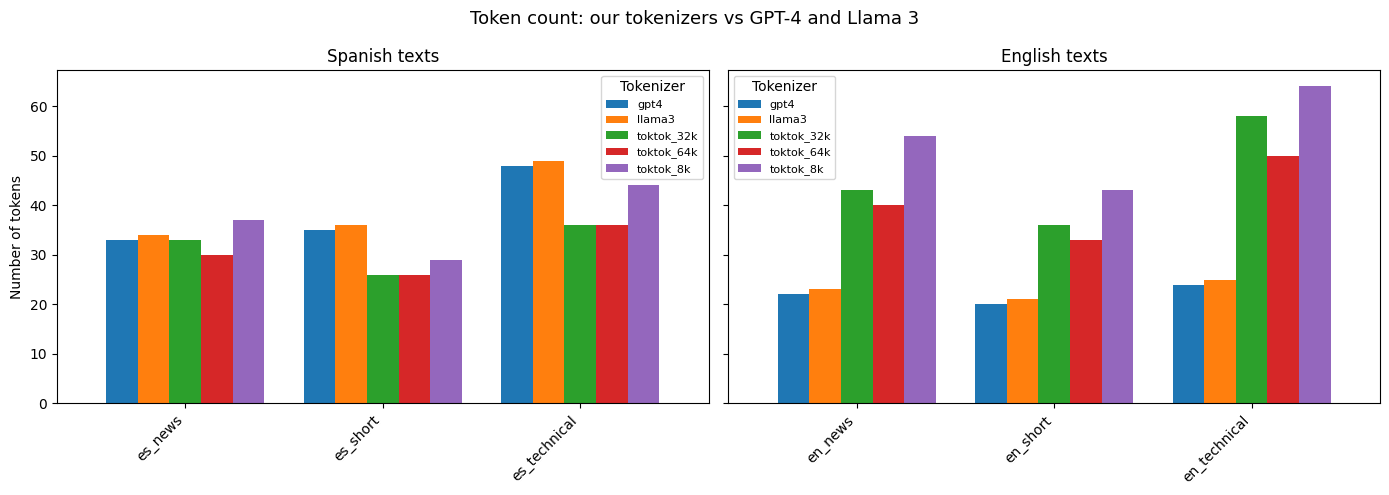

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, lang in enumerate(["Spanish", "English"]):
    ax = axes[i]
    lang_df = df[df["lang"] == lang]
    pivot = lang_df.pivot(index="text", columns="tokenizer", values="n_tokens")
    pivot.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(f"{lang} texts")
    ax.set_ylabel("Number of tokens" if i == 0 else "")
    ax.set_xlabel("")
    ax.legend(title="Tokenizer", fontsize=8)
    plt.sca(ax)
    plt.xticks(rotation=45, ha="right")

plt.suptitle("Token count: our tokenizers vs GPT-4 and Llama 3", fontsize=13)
plt.tight_layout()
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/compression_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Zipf's law check

A good tokenizer should produce a token frequency distribution that follows Zipf's law:
the most common token appears roughly twice as often as the second most common, three times as often as the third, etc.

We tokenize a large chunk of spanish text and check.

Sample: 5,000,000 chars
Tokens: 1,043,361
Unique tokens used: 29,817 / 32,000


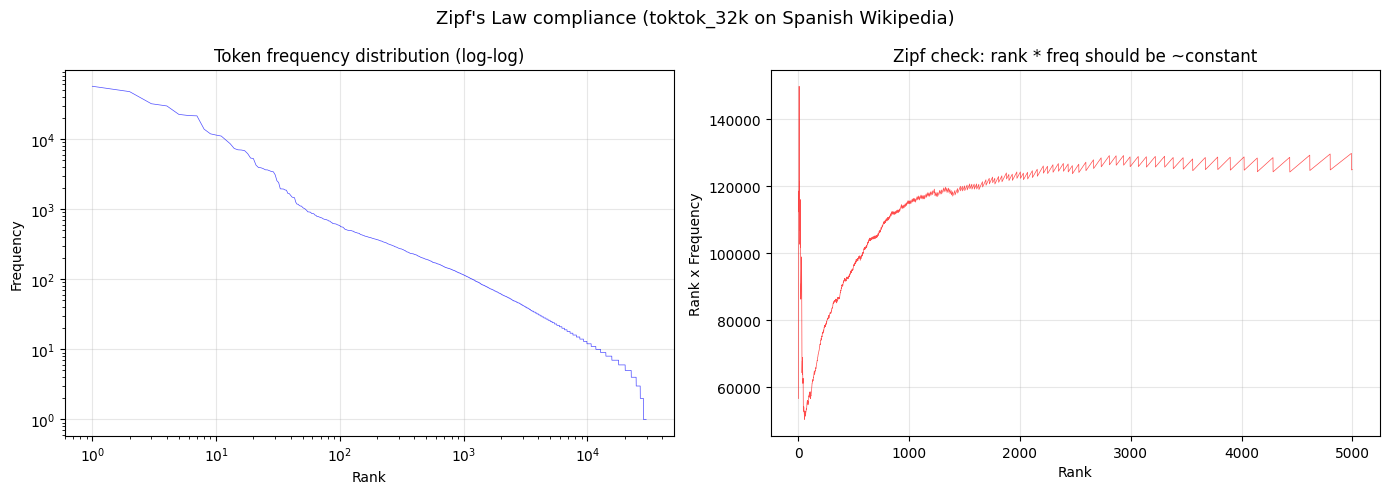


Top 20 tokens:
  ▁de                  (id=  262): 56,569
  ,                    (id=31903): 47,427
  .                    (id=31906): 31,860
  ▁la                  (id=  275): 29,631
  ▁y                   (id=  291): 22,462
  ▁el                  (id=  290): 21,614
  ▁en                  (id=  280): 21,403
  ▁que                 (id=  305): 13,828
  ▁los                 (id=  313): 11,858
  ▁a                   (id=  269): 11,383
  ▁del                 (id=  317): 11,029
  ▁se                  (id=  309): 9,689
  ▁las                 (id=  331): 8,560
  ▁(                   (id=  325): 7,331
  ▁por                 (id=  341): 7,017
  ▁un                  (id=  304): 6,970
  ▁con                 (id=  301): 6,822
  ▁una                 (id=  352): 6,183
  ▁es                  (id=  295): 5,349
  ▁como                (id=  366): 5,273


In [7]:
# read a sample of the corpus
with open("data/es_wiki.txt", "r", encoding="utf-8") as f:
    sample_text = f.read(5_000_000)  # 5MB sample

print(f"Sample: {len(sample_text):,} chars")

# tokenize with our 32k model and count frequencies
sp_32k = models["toktok_32k"]
ids = sp_32k.encode_as_ids(sample_text)
freq = Counter(ids)
print(f"Tokens: {len(ids):,}")
print(f"Unique tokens used: {len(freq):,} / {sp_32k.get_piece_size():,}")

# sort by frequency
sorted_freqs = sorted(freq.values(), reverse=True)
ranks = range(1, len(sorted_freqs) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: rank vs frequency (log-log)
ax = axes[0]
ax.loglog(ranks, sorted_freqs, "b-", alpha=0.7, linewidth=0.5)
ax.set_xlabel("Rank")
ax.set_ylabel("Frequency")
ax.set_title("Token frequency distribution (log-log)")
ax.grid(True, alpha=0.3)

# plot 2: rank * frequency should be roughly constant for Zipf
ax = axes[1]
zipf_product = [r * f for r, f in zip(ranks, sorted_freqs)]
ax.plot(list(ranks)[:5000], zipf_product[:5000], "r-", alpha=0.7, linewidth=0.5)
ax.set_xlabel("Rank")
ax.set_ylabel("Rank x Frequency")
ax.set_title("Zipf check: rank * freq should be ~constant")
ax.grid(True, alpha=0.3)

plt.suptitle("Zipf's Law compliance (toktok_32k on Spanish Wikipedia)", fontsize=13)
plt.tight_layout()
plt.savefig("plots/zipf.png", dpi=150, bbox_inches="tight")
plt.show()

# show top tokens
print("\nTop 20 tokens:")
for token_id, count in freq.most_common(20):
    piece = sp_32k.id_to_piece(token_id)
    print(f"  {piece:20s} (id={token_id:5d}): {count:,}")

## 6. Vocab size sweet spot

We trained at 8K, 32K, and 64K. Lets find which vocab size gives the best compression for spanish without being too large.

Token indices sequence length is longer than the specified maximum sequence length for this model (1392597 > 131072). Running this sequence through the model will result in indexing errors


 tokenizer  vocab_size  n_tokens  compression
 toktok_8k        8000   1283303     3.896196
toktok_32k       32000   1043361     4.792205
toktok_64k       64000    976342     5.121156
      gpt4      100277   1398271     3.575845
    llama3      128000   1392597     3.590414


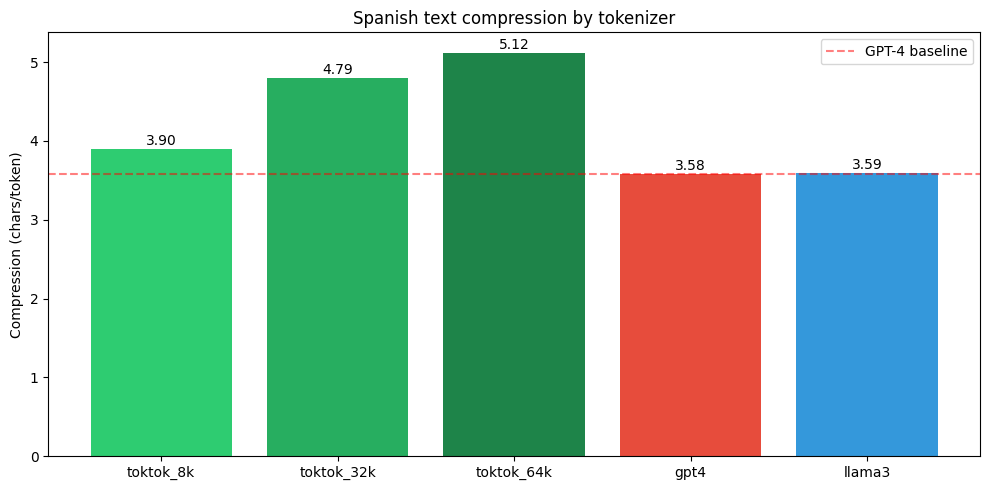

In [8]:
# tokenize the same large sample with each model
vocab_results = []
for name, sp in models.items():
    ids = sp.encode_as_ids(sample_text)
    vocab_results.append({
        "tokenizer": name,
        "vocab_size": sp.get_piece_size(),
        "n_tokens": len(ids),
        "compression": len(sample_text) / len(ids),
    })

# also test GPT-4 and Llama
gpt4_ids = gpt4_enc.encode(sample_text)
vocab_results.append({
    "tokenizer": "gpt4",
    "vocab_size": gpt4_enc.n_vocab,
    "n_tokens": len(gpt4_ids),
    "compression": len(sample_text) / len(gpt4_ids),
})

llama_ids = llama_tok.encode(sample_text)
vocab_results.append({
    "tokenizer": "llama3",
    "vocab_size": llama_tok.vocab_size,
    "n_tokens": len(llama_ids),
    "compression": len(sample_text) / len(llama_ids),
})

vdf = pd.DataFrame(vocab_results)
print(vdf.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71", "#27ae60", "#1e8449", "#e74c3c", "#3498db"]
bars = ax.bar(vdf["tokenizer"], vdf["compression"], color=colors)
ax.set_ylabel("Compression (chars/token)")
ax.set_title("Spanish text compression by tokenizer")
ax.axhline(y=vdf[vdf["tokenizer"] == "gpt4"]["compression"].values[0], color="red", linestyle="--", alpha=0.5, label="GPT-4 baseline")

for bar, row in zip(bars, vdf.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{row.compression:.2f}", ha="center", fontsize=10)

ax.legend()
plt.tight_layout()
plt.savefig("plots/vocab_sweet_spot.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.5 Normalized efficiency: compression per vocab token

Raw compression isn't a fair comparison when vocab sizes differ by 4-16x. To level the playing field, we normalize: **how much compression does each tokenizer get per 1K vocab entries?**

This answers: who uses their vocab budget more efficiently on Spanish?

Normalized efficiency (compression per 1K vocab entries):
 tokenizer  vocab_size  compression  efficiency
 toktok_8k        8000     3.896196    0.487024
toktok_32k       32000     4.792205    0.149756
toktok_64k       64000     5.121156    0.080018
      gpt4      100277     3.575845    0.035660
    llama3      128000     3.590414    0.028050


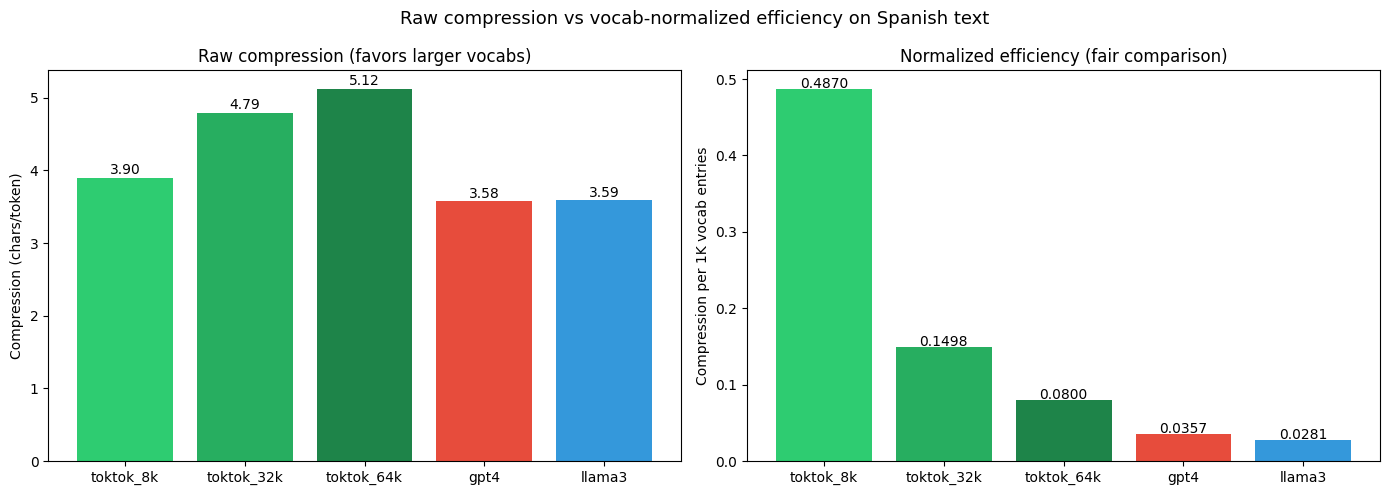

In [9]:
# normalized efficiency: compression per 1K vocab entries
vdf["efficiency"] = vdf["compression"] / (vdf["vocab_size"] / 1000)

print("Normalized efficiency (compression per 1K vocab entries):")
print(vdf[["tokenizer", "vocab_size", "compression", "efficiency"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: raw compression (what we had before)
ax = axes[0]
colors = ["#2ecc71", "#27ae60", "#1e8449", "#e74c3c", "#3498db"]
bars = ax.bar(vdf["tokenizer"], vdf["compression"], color=colors)
ax.set_ylabel("Compression (chars/token)")
ax.set_title("Raw compression (favors larger vocabs)")
for bar, row in zip(bars, vdf.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{row.compression:.2f}", ha="center", fontsize=10)

# right: normalized efficiency
ax = axes[1]
bars = ax.bar(vdf["tokenizer"], vdf["efficiency"], color=colors)
ax.set_ylabel("Compression per 1K vocab entries")
ax.set_title("Normalized efficiency (fair comparison)")
for bar, row in zip(bars, vdf.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{row.efficiency:.4f}", ha="center", fontsize=10)

plt.suptitle("Raw compression vs vocab-normalized efficiency on Spanish text", fontsize=13)
plt.tight_layout()
plt.savefig("plots/normalized_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Token-level comparison

Lets look at how each tokenizer splits the same spanish sentences. This shows exactly where english tokenizers waste tokens.

In [10]:
comparison_texts = [
    "La inteligencia artificial esta transformando el mundo.",
    "El aprendizaje automatico permite a las maquinas aprender de los datos.",
    "Los modelos de lenguaje grandes pueden generar texto coherente y util.",
]

for text in comparison_texts:
    print(f"Text: {text}")
    print("-" * 80)
    
    # our 32k
    pieces = sp_32k.encode_as_pieces(text)
    print(f"  TokTok 32K ({len(pieces):2d} tok): |{'|'.join(pieces)}|")
    
    # GPT-4
    gpt4_tokens = gpt4_enc.encode(text)
    gpt4_decoded = [gpt4_enc.decode([t]) for t in gpt4_tokens]
    print(f"  GPT-4      ({len(gpt4_tokens):2d} tok): |{'|'.join(gpt4_decoded)}|")
    
    # Llama
    llama_ids = llama_tok.encode(text)
    llama_tokens = llama_tok.convert_ids_to_tokens(llama_ids)
    llama_display = [t.replace('Ġ', ' ').replace('▁', ' ') for t in llama_tokens]
    print(f"  Llama 3    ({len(llama_ids):2d} tok): |{'|'.join(llama_display)}|")
    
    print()

Text: La inteligencia artificial esta transformando el mundo.
--------------------------------------------------------------------------------
  TokTok 32K ( 9 tok): |▁La|▁inteligencia|▁artificial|▁esta|▁transfor|mando|▁el|▁mundo|.|
  GPT-4      (10 tok): |La| intelig|encia| artificial| esta| transform|ando| el| mundo|.|
  Llama 3    (11 tok): |<|begin_of_text|>|La| intelig|encia| artificial| esta| transform|ando| el| mundo|.|

Text: El aprendizaje automatico permite a las maquinas aprender de los datos.
--------------------------------------------------------------------------------
  TokTok 32K (14 tok): |▁El|▁aprendizaje|▁automa|tico|▁permite|▁a|▁las|▁ma|quinas|▁aprender|▁de|▁los|▁datos|.|
  GPT-4      (17 tok): |El| aprend|iz|aje| automatic|o| permite| a| las| ma|qu|inas| aprender| de| los| datos|.|
  Llama 3    (18 tok): |<|begin_of_text|>|El| aprend|iz|aje| automatic|o| permite| a| las| ma|qu|inas| aprender| de| los| datos|.|

Text: Los modelos de lenguaje grandes pueden generar 

## 8. The tradeoff: English degradation

A Spanish-only tokenizer wins on Spanish by design. But what does it **lose**? If you're building a bilingual system, this is the critical question. Let's measure how badly our tokenizer handles English compared to the general-purpose ones.

We tokenize the English Wikipedia sample with all tokenizers and compare compression ratios on both languages side by side.

English sample: 5,000,000 chars
Spanish sample: 5,000,000 chars



Compression by language:
 tokenizer  es_compression  en_compression  es_en_ratio
 toktok_8k            3.90            2.58         1.51
toktok_32k            4.79            3.05         1.57
toktok_64k            5.12            3.34         1.53
      gpt4            3.58            4.62         0.77
    llama3            3.59            4.63         0.78


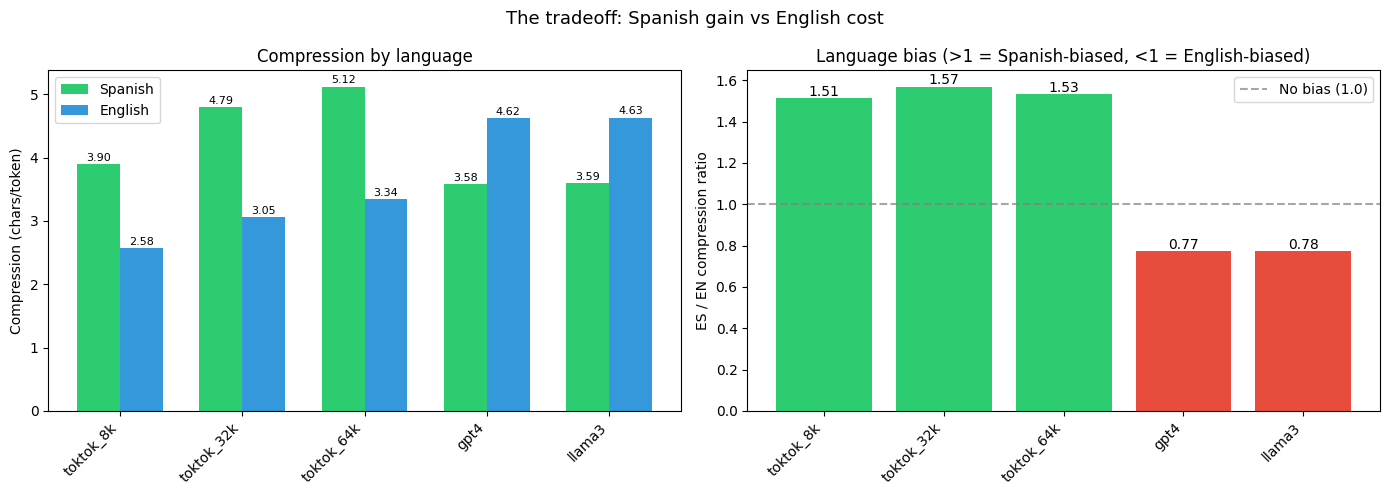


toktok_32k vs GPT-4:
  Spanish gain: +34.0% better compression
  English cost: -34.0% worse compression
  Verdict: Worth it for Spanish-only workloads


In [11]:
# load english sample
en_path = "data/en_wiki.txt"
if not os.path.exists(en_path):
    print(f"{en_path} not found — run: python download_data.py --english")
else:
    with open(en_path, "r", encoding="utf-8") as f:
        en_sample = f.read(5_000_000)  # 5MB to match spanish sample
    print(f"English sample: {len(en_sample):,} chars")
    print(f"Spanish sample: {len(sample_text):,} chars")

    # compression on both languages for every tokenizer
    tradeoff_rows = []
    tokenizers_all = {
        **{name: ("sp", tok) for name, tok in models.items()},
        "gpt4": ("tiktoken", gpt4_enc),
        "llama3": ("hf", llama_tok),
    }

    for name, (tok_type, tok) in tokenizers_all.items():
        es_tokens = count_tokens(sample_text, tok, tok_type)
        en_tokens = count_tokens(en_sample, tok, tok_type)
        es_comp = len(sample_text) / es_tokens
        en_comp = len(en_sample) / en_tokens
        tradeoff_rows.append({
            "tokenizer": name,
            "es_compression": es_comp,
            "en_compression": en_comp,
            "es_en_ratio": es_comp / en_comp,  # >1 = better at spanish, <1 = better at english
        })

    tdf = pd.DataFrame(tradeoff_rows)
    print("\nCompression by language:")
    print(tdf.to_string(index=False, float_format="%.2f"))

    # plot: grouped bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # left: compression on each language
    ax = axes[0]
    x = np.arange(len(tdf))
    width = 0.35
    bars_es = ax.bar(x - width/2, tdf["es_compression"], width, label="Spanish", color="#2ecc71")
    bars_en = ax.bar(x + width/2, tdf["en_compression"], width, label="English", color="#3498db")
    ax.set_ylabel("Compression (chars/token)")
    ax.set_title("Compression by language")
    ax.set_xticks(x)
    ax.set_xticklabels(tdf["tokenizer"], rotation=45, ha="right")
    ax.legend()
    for bar in bars_es:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{bar.get_height():.2f}", ha="center", fontsize=8)
    for bar in bars_en:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{bar.get_height():.2f}", ha="center", fontsize=8)

    # right: ES/EN ratio — shows the language bias
    ax = axes[1]
    colors_ratio = ["#2ecc71" if r > 1 else "#e74c3c" for r in tdf["es_en_ratio"]]
    bars = ax.bar(tdf["tokenizer"], tdf["es_en_ratio"], color=colors_ratio)
    ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.7, label="No bias (1.0)")
    ax.set_ylabel("ES / EN compression ratio")
    ax.set_title("Language bias (>1 = Spanish-biased, <1 = English-biased)")
    ax.legend()
    for bar, val in zip(bars, tdf["es_en_ratio"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", fontsize=10)
    plt.xticks(rotation=45, ha="right")

    plt.suptitle("The tradeoff: Spanish gain vs English cost", fontsize=13)
    plt.tight_layout()
    plt.savefig("plots/tradeoff.png", dpi=150, bbox_inches="tight")
    plt.show()

    # quantify the degradation
    gpt4_row = tdf[tdf["tokenizer"] == "gpt4"].iloc[0]
    toktok32_row = tdf[tdf["tokenizer"] == "toktok_32k"].iloc[0]
    es_gain = (toktok32_row["es_compression"] / gpt4_row["es_compression"] - 1) * 100
    en_cost = (1 - toktok32_row["en_compression"] / gpt4_row["en_compression"]) * 100
    print(f"\ntoktok_32k vs GPT-4:")
    print(f"  Spanish gain: +{es_gain:.1f}% better compression")
    print(f"  English cost: -{en_cost:.1f}% worse compression")
    print(f"  Verdict: {'Worth it for Spanish-only workloads' if es_gain > en_cost else 'Mixed — consider bilingual needs'}")

## Key takeaways

**The comparison is not apples-to-apples — and that's the point.**

Our tokenizer spends 32K vocab entries exclusively on Spanish. GPT-4 spreads 100K entries across all languages + code. Llama 3 spreads 128K. Comparing raw compression is unfair by design — the normalized efficiency metric (section 6.5) gives a fairer picture.

**What Spanish-specific tokenization buys you**

On Spanish text, toktok_32k compresses better than GPT-4 despite having 3x fewer vocab entries. Per vocab token, it's dramatically more efficient. This matters if you're building a Spanish-only system: fewer tokens = cheaper inference, longer effective context windows.

**What it costs you**

On English text, our tokenizer is significantly worse than GPT-4 and Llama 3 (see section 8). This is the expected and honest tradeoff: a language-specific tokenizer gains on its target language and loses on everything else.

**When to use this**

- **Spanish-only workloads**: toktok is the clear winner — better compression with a smaller vocab
- **Bilingual EN/ES**: consider the tradeoff numbers from section 8 — if your workload is >70% Spanish, it may still be worth it
- **Multilingual**: stick with GPT-4 or Llama 3 tokenizers — they're designed for this

**Sweet spot vocab size**

32K gives the best balance for Spanish. Going from 8K to 32K is a big jump in compression. Going from 32K to 64K gives diminishing returns.

**Zipf's law**

Our tokenizer follows Zipf's law nicely, meaning the vocabulary is well-distributed and healthy.